In [1]:
## import ROOT
import pandas as pd
import seaborn as sns
import numpy as np

NUMBER_OF_BARS = 1300

Welcome to JupyROOT 6.30/08


In [2]:
canvas = ROOT.TCanvas("canvas", "canvas", 500, 600)

In [3]:
filename = "/lustre/r3b/ywang/test/neuland_test/cal.root"

file = ROOT.TFile(filename, "read")

In [4]:
hist_dir = file.Get("DataMonitor/NeulandCal2HitParTask")
hist_dir.ls()


TDirectoryFile*		NeulandCal2HitParTask	NeulandCal2HitParTask
 KEY: TH1I	condition_check;1	check the condition
 KEY: TH2D	hist_time_diff;1	Time differences between two adjacent PMTs
 KEY: TH2D	hist_time_sum;1	Time summation between two adjacent PMTs
 KEY: TH1I	trig_check;1	check the triggered or passed events


In [5]:
par_filename = "/lustre/r3b/ywang/test/neuland_test/digi40M.par.root.0"

par_file = ROOT.TFile(par_filename, "read")
par_file.ls()

TFile**		/lustre/r3b/ywang/test/neuland_test/digi40M.par.root.0	
 TFile*		/lustre/r3b/ywang/test/neuland_test/digi40M.par.root.0	
  KEY: R3B::Neuland::Cal2HitPar	NeulandHitPar;2	Neuland Cal2Hit calibration [current cycle]
  KEY: R3B::Neuland::Cal2HitPar	NeulandHitPar;1	Neuland Cal2Hit calibration [backup cycle]
  KEY: FairGeoParSet	FairGeoParSet;2	class for Geo parameter [current cycle]
  KEY: FairGeoParSet	FairGeoParSet;1	class for Geo parameter [backup cycle]
  KEY: FairBaseParSet	FairBaseParSet;2	class for parameter io [current cycle]
  KEY: FairBaseParSet	FairBaseParSet;1	class for parameter io [backup cycle]
  KEY: TProcessID	ProcessID0;1	4453266c-de42-11ef-88a5-0d00140abeef
  KEY: R3BNeulandGeoPar	R3BNeulandGeoPar;2	Neuland Geometry Parameters [current cycle]
  KEY: R3BNeulandGeoPar	R3BNeulandGeoPar;1	Neuland Geometry Parameters [backup cycle]
  KEY: R3BFieldPar	R3BFieldPar;2	Parameter for R3B field [current cycle]
  KEY: R3BFieldPar	R3BFieldPar;1	Parameter for R3B field [backup 

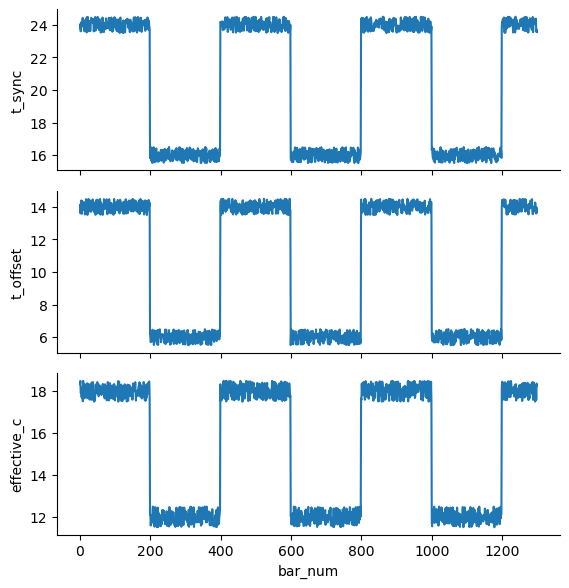

In [6]:
hit_par = par_file.Get("NeulandHitPar")

t_syncs = np.zeros(NUMBER_OF_BARS)
t_diffs = np.zeros(NUMBER_OF_BARS)
light_attenuation_lengths = np.zeros(NUMBER_OF_BARS)
energy_gain = np.zeros(NUMBER_OF_BARS)
pedestals = np.zeros(NUMBER_OF_BARS)
pmt_threshs = np.zeros(NUMBER_OF_BARS)
saturation_coefficients = np.zeros(NUMBER_OF_BARS)
effective_c = np.zeros(NUMBER_OF_BARS)

for bar_id in range(0, NUMBER_OF_BARS):
    bar_num = bar_id + 1
    t_syncs[bar_id] = hit_par.GetModuleParAt(bar_num).tSync.value
    t_diffs[bar_id] = hit_par.GetModuleParAt(bar_num).tDiff.value
    light_attenuation_lengths[bar_id] = hit_par.GetModuleParAt(bar_num).lightAttenuationLength.value
    energy_gain[bar_id] = hit_par.GetModuleParAt(bar_num).energyGain.left().value
    pedestals[bar_id] = hit_par.GetModuleParAt(bar_num).pedestal.left()
    pmt_threshs[bar_id] = hit_par.GetModuleParAt(bar_num).PMTThreshold.left().value
    saturation_coefficients[bar_id] = hit_par.GetModuleParAt(bar_num).PMTSaturation.left().value
    effective_c[bar_id] = hit_par.GetModuleParAt(bar_num).effectiveSpeed.value

data_frame = pd.DataFrame({"bar_num": range(NUMBER_OF_BARS), "t_sync": t_syncs, "t_offset": t_diffs, "effective_c": effective_c})

g = sns.PairGrid(data = data_frame, x_vars = ["bar_num"], y_vars = ["t_sync", "t_offset", "effective_c"], height = 2, aspect = 3)
g.map_offdiag(sns.lineplot)
# sns.lineplot(data = data_frame, x = 'bar_num', y = 't_offset', linewidth = 0.8);
# sns.lineplot(data = data_frame, x = 'bar_num', y = 't_sync', linewidth = 0.8);


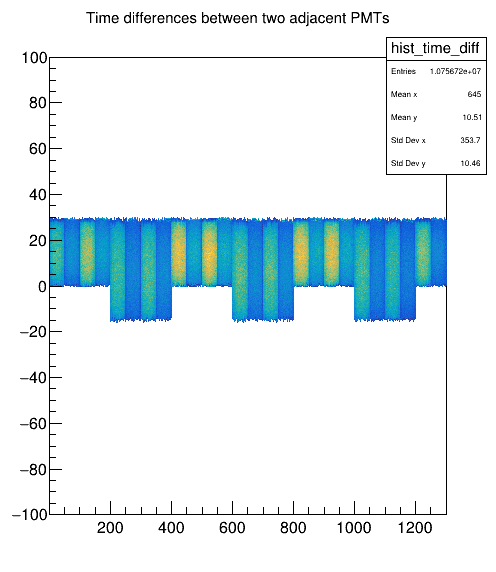

In [35]:
hist_time_diff = hist_dir.Get("hist_time_diff")
hist_time_diff.Draw()
canvas.Draw()

quanties 0.05: -11.553999999999993, 0.95: 26.367500000000007
effective_speed: 12.620799114416899
t_offset: 6.713239805677347
effective_speed: 12.620799114416899
t_offset: 6.713239805677347
****************************************
Minimizer is Linear / Migrad
Chi2                      =      130.883
NDf                       =           93
p0                        =     0.330547   +/-   0.00114788  
p1                        =    0.0252416   +/-   0.000112979 
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      130.883
NDf                       =           93
Edm                       =  1.49264e-22
NCalls                    =           20
p0                        =      6.71324   +/-   0.0571992   
p1                        =    0.0252416   +/-   0.000113016 


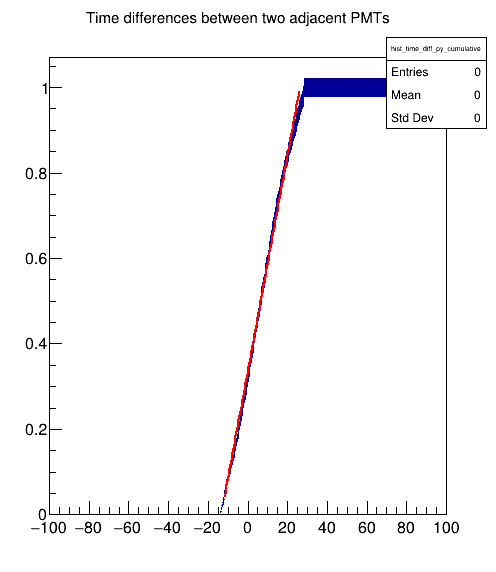

In [74]:
module_num = 200
hist_y = hist_time_diff.ProjectionY("_py", module_num, module_num)
hist_y.Scale(1 / hist_y.GetEntries())
cumulative_hist = hist_y.GetCumulative()
cumulative_hist.Draw()

n = 2
length =250. 

xp = np.zeros(n)
p = np.array([0.05, 0.95])
hist_y.GetQuantiles(n, xp, p)
canvas.Draw()
print(f"quanties 0.05: {xp[0]}, 0.95: {xp[1]}")


first_res = cumulative_hist.Fit("pol1", "SQ", "", xp[0], xp[1])
first_res.Print()
print(f"effective_speed: {2 * length * first_res.Parameter(1)}")
print(f"t_offset: {(0.5  - first_res.Parameter(0)) / first_res.Parameter(1)}")

fit_fun = ROOT.TF1("fit_fun", f"[1]*x + 0.5 - [0] * [1]", xp[0], xp[1] )
fit_fun.SetParameter(0, (0.5 - first_res.Parameter(0)) / first_res.Parameter(1))
fit_fun.SetParameter(1, first_res.Parameter(1))
res = cumulative_hist.Fit(fit_fun, "SQ", "", xp[0], xp[1])
print(f"effective_speed: {2 * length * res.Parameter(1)}")
print(f"t_offset: {res.Parameter(0)}")
res.Print()

# pars = res.Parameters()
# print(res.Parameters())
# print(res.Errors())
# print("effective speed: {}")

In [64]:
1/ 0.025

40.0

In [75]:
par = ROOT.R3B.Neuland.HitModulePar()

In [79]:
hasattr(par.tDiff, "asd")

TypeError: Template method resolution failed:
  Failed to instantiate "operator*()"

In [84]:
'value' in dir(par.tDiff)

True

In [90]:
getattr(ROOT.R3B.Neuland.HitModulePar(), 'tDiff').value

0.0